In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import superstats as sup
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


In [3]:
NUM_STEPS = 100

In [4]:
prior = sup.JointPrior(
    v = sup.transition.RandomWalk(bounds=(0.0, 6.0)),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(),
            sup.transition.Jump()
        ]
    ),
    tau = sup.transition.RandomWalk(bounds=(0.0, 2.0)),
    bias = 0.5
)

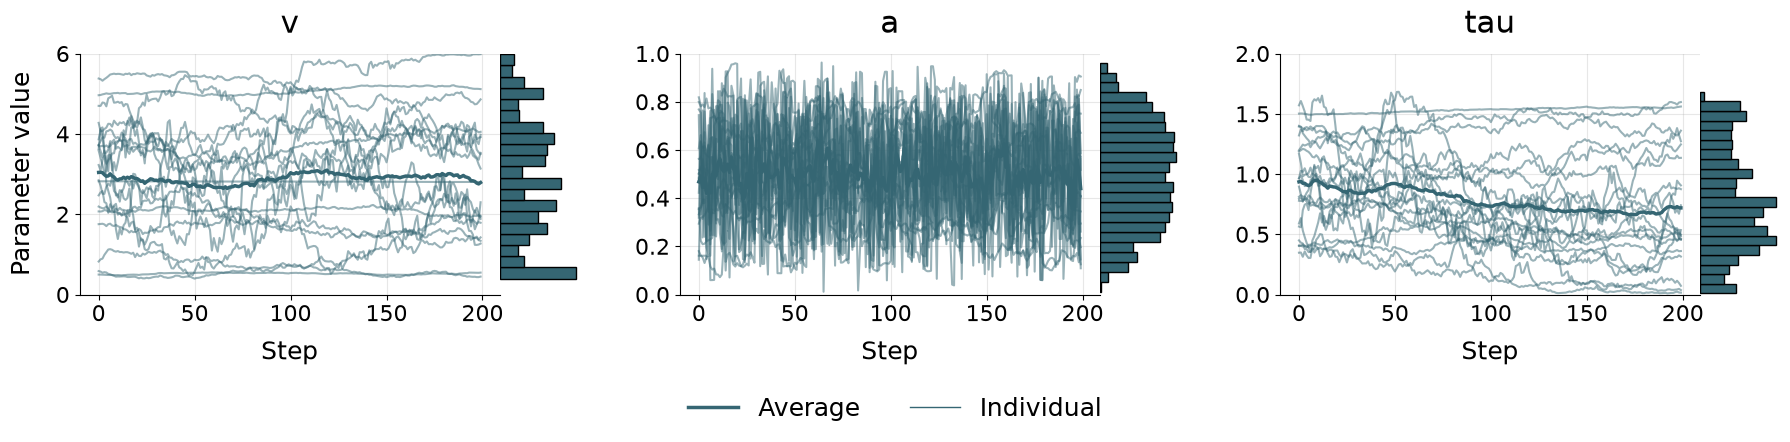

In [5]:
fig = prior.plot_time_varying_prior()

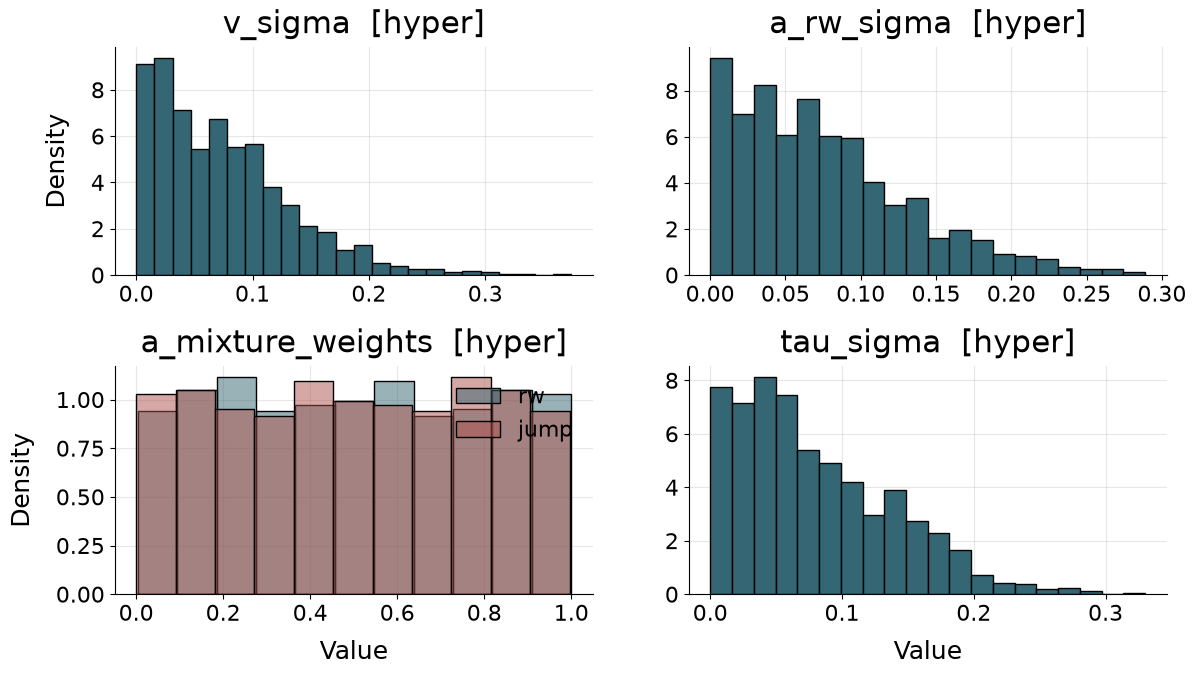

In [6]:
fig = prior.plot_time_invariant_prior()

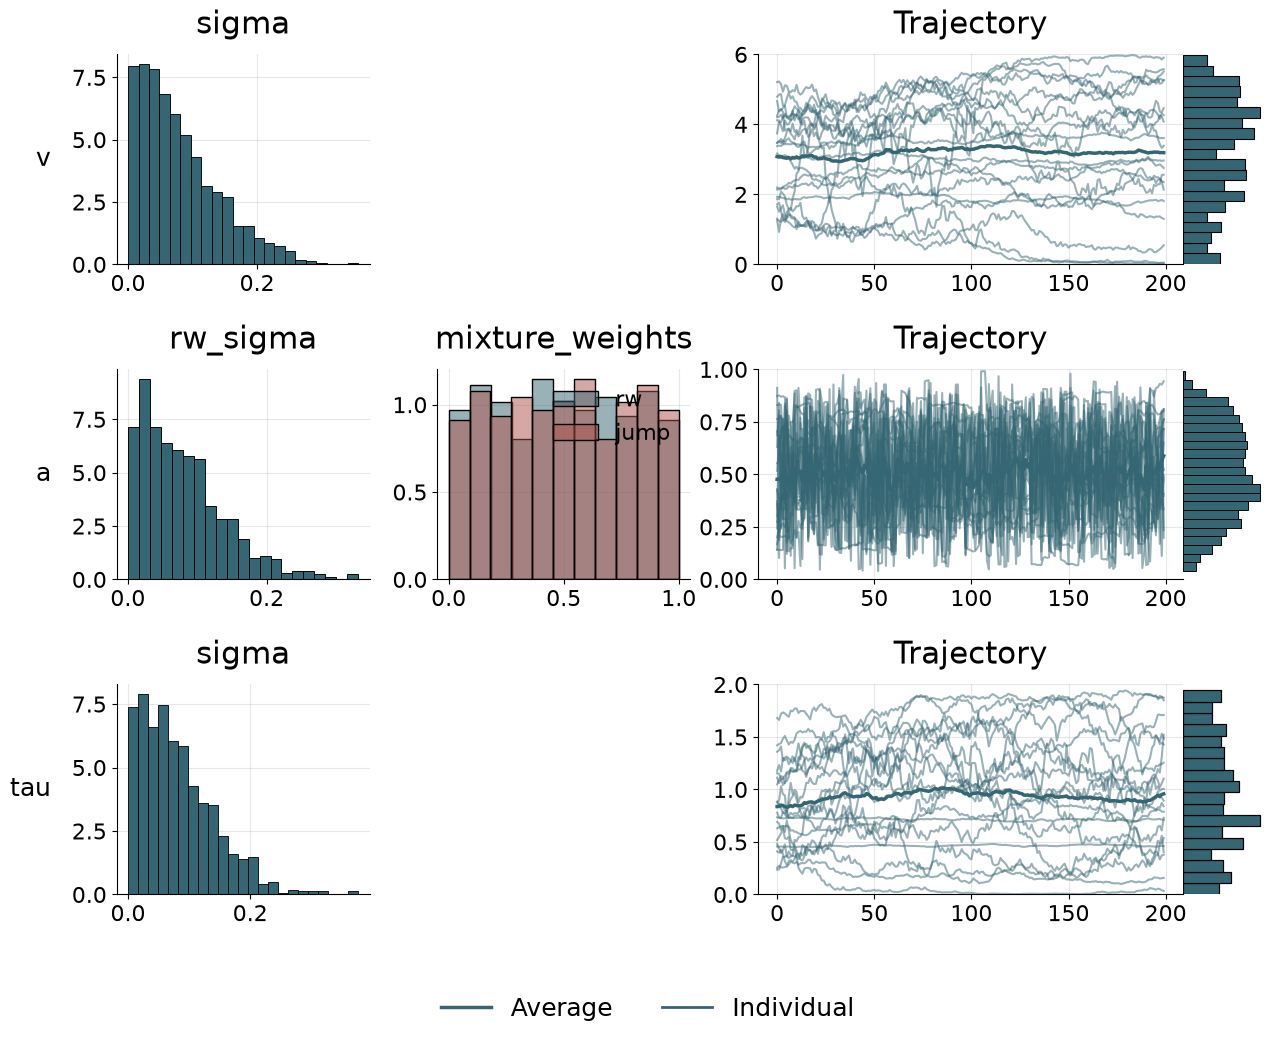

In [7]:
fig = prior.plot_joint_prior()

In [8]:
contamination = sup.simulation.RandomChoiceContamination(
    p_contaminated=sup.transition.RandomWalk(
        bounds=(0.0, 1.0),
        sigma=sup.Prior("halfnormal", scale=0.05),
        delta=0.0,
    ),
    infer=True,
)

In [9]:
model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    missing=None,
    contamination=contamination
)

In [10]:
sim_data = model.sample(32, NUM_STEPS)
sim_data.keys()
model.hyper_keys

['v_sigma',
 'a_rw_sigma',
 'a_mixture_weights',
 'tau_sigma',
 'p_contaminated_sigma']

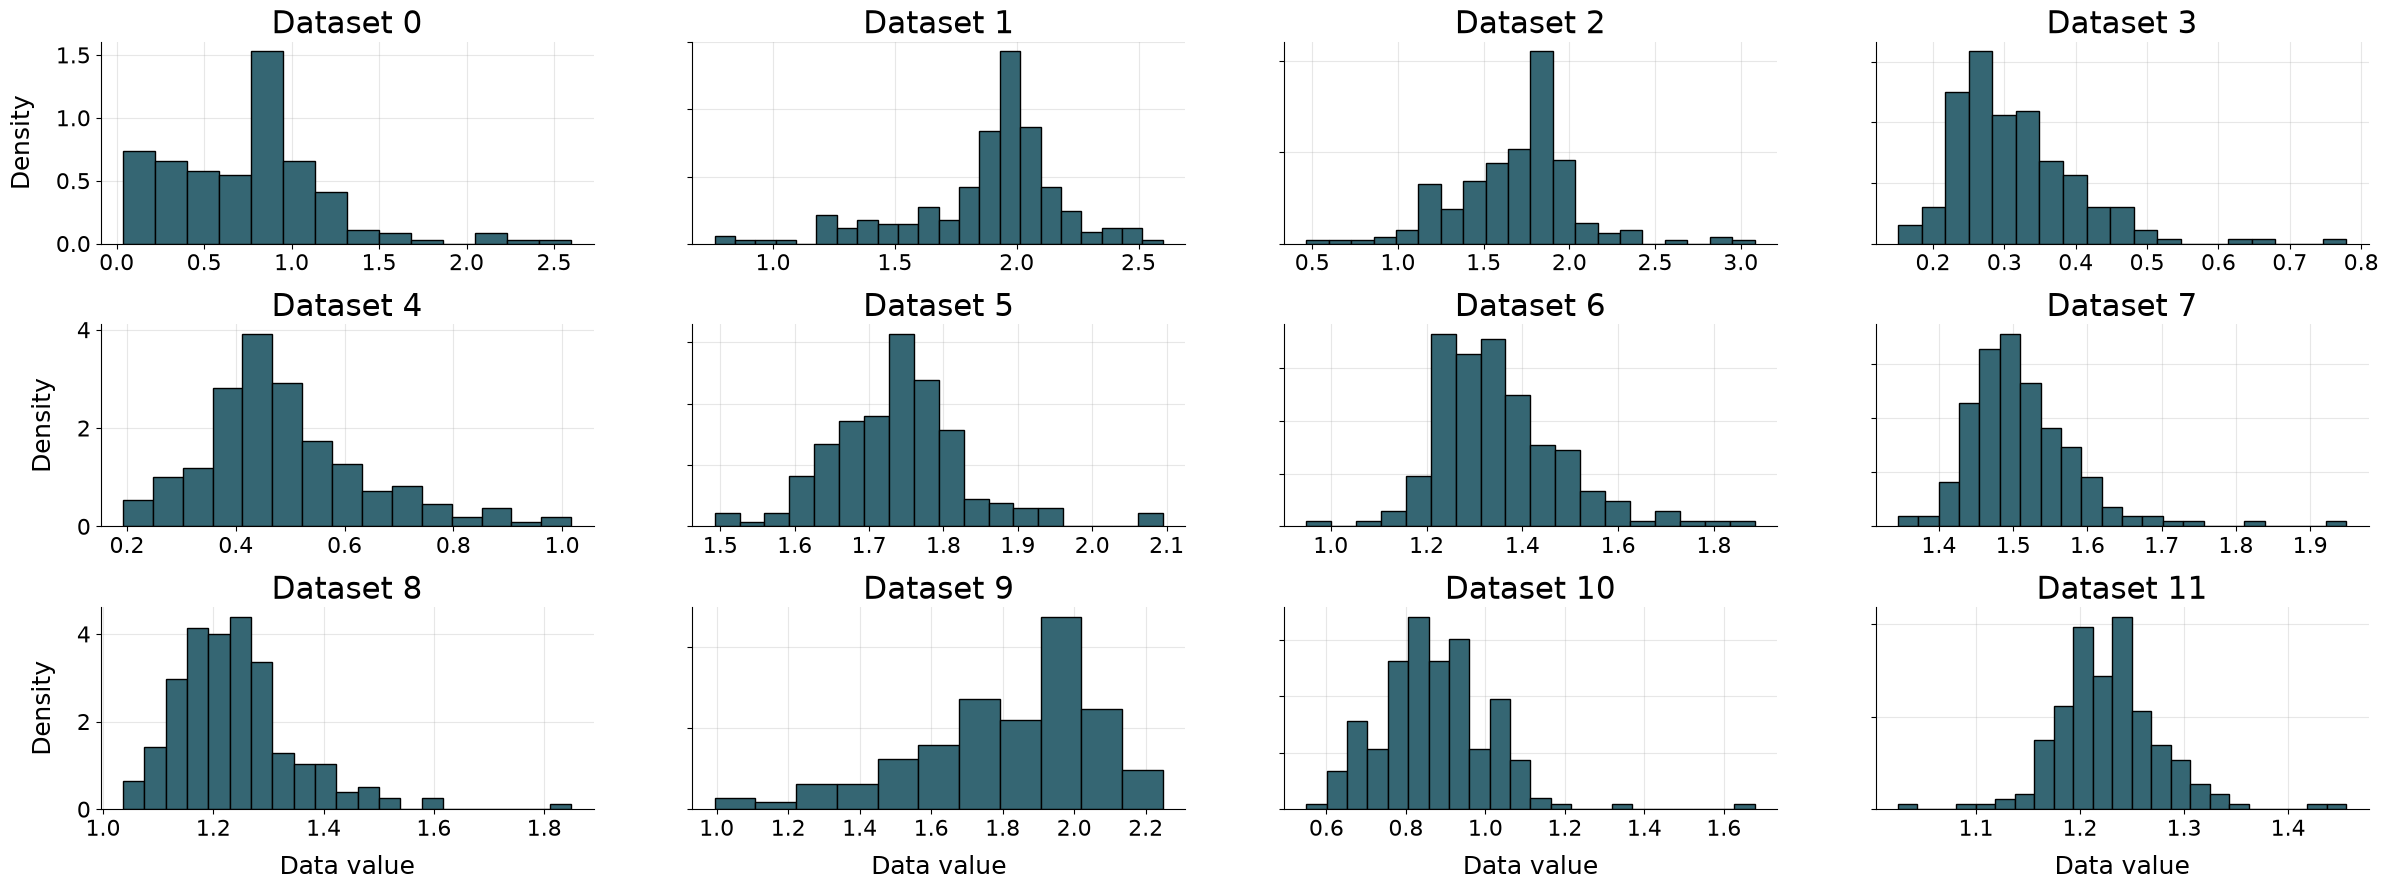

In [11]:
fig = model.plot_push_forward(
    batch_size=12,
    kind="dist",
    dist_type="hist",
)

In [14]:
workflow = sup.Workflow(
    model=model,
    # embedding_network=sup.networks.RecurrentNet(),
    inference_network="coupling"
)

In [15]:
train_data = model.sample(
    batch_size=20,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
val_data = model.sample(
    batch_size=10,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [16]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=2,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 14.1894 - val_loss: 14.1700
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 14.1357 - val_loss: 14.1548


INFO:bayesflow:Training completed in 6.40 seconds.


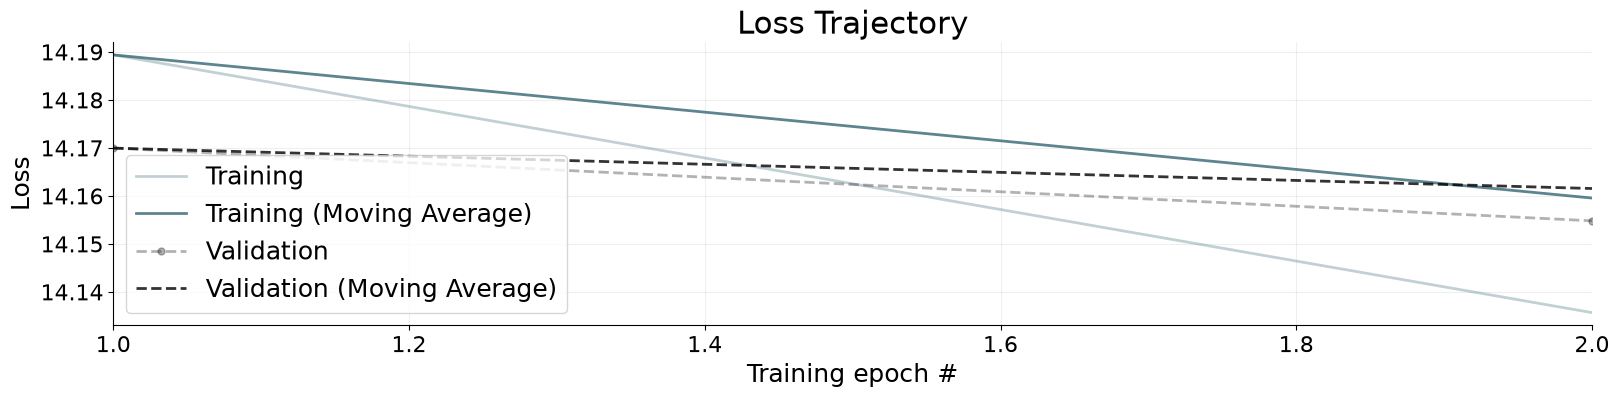

In [17]:
fig = workflow.plot_history(workflow.history)

In [18]:
samples = workflow.sample(
    data=val_data,
    num_samples=100,
    batch_size=2
)

Summarizing:   0%|          | 0/5 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/5 [00:00<?, ?batch/s]

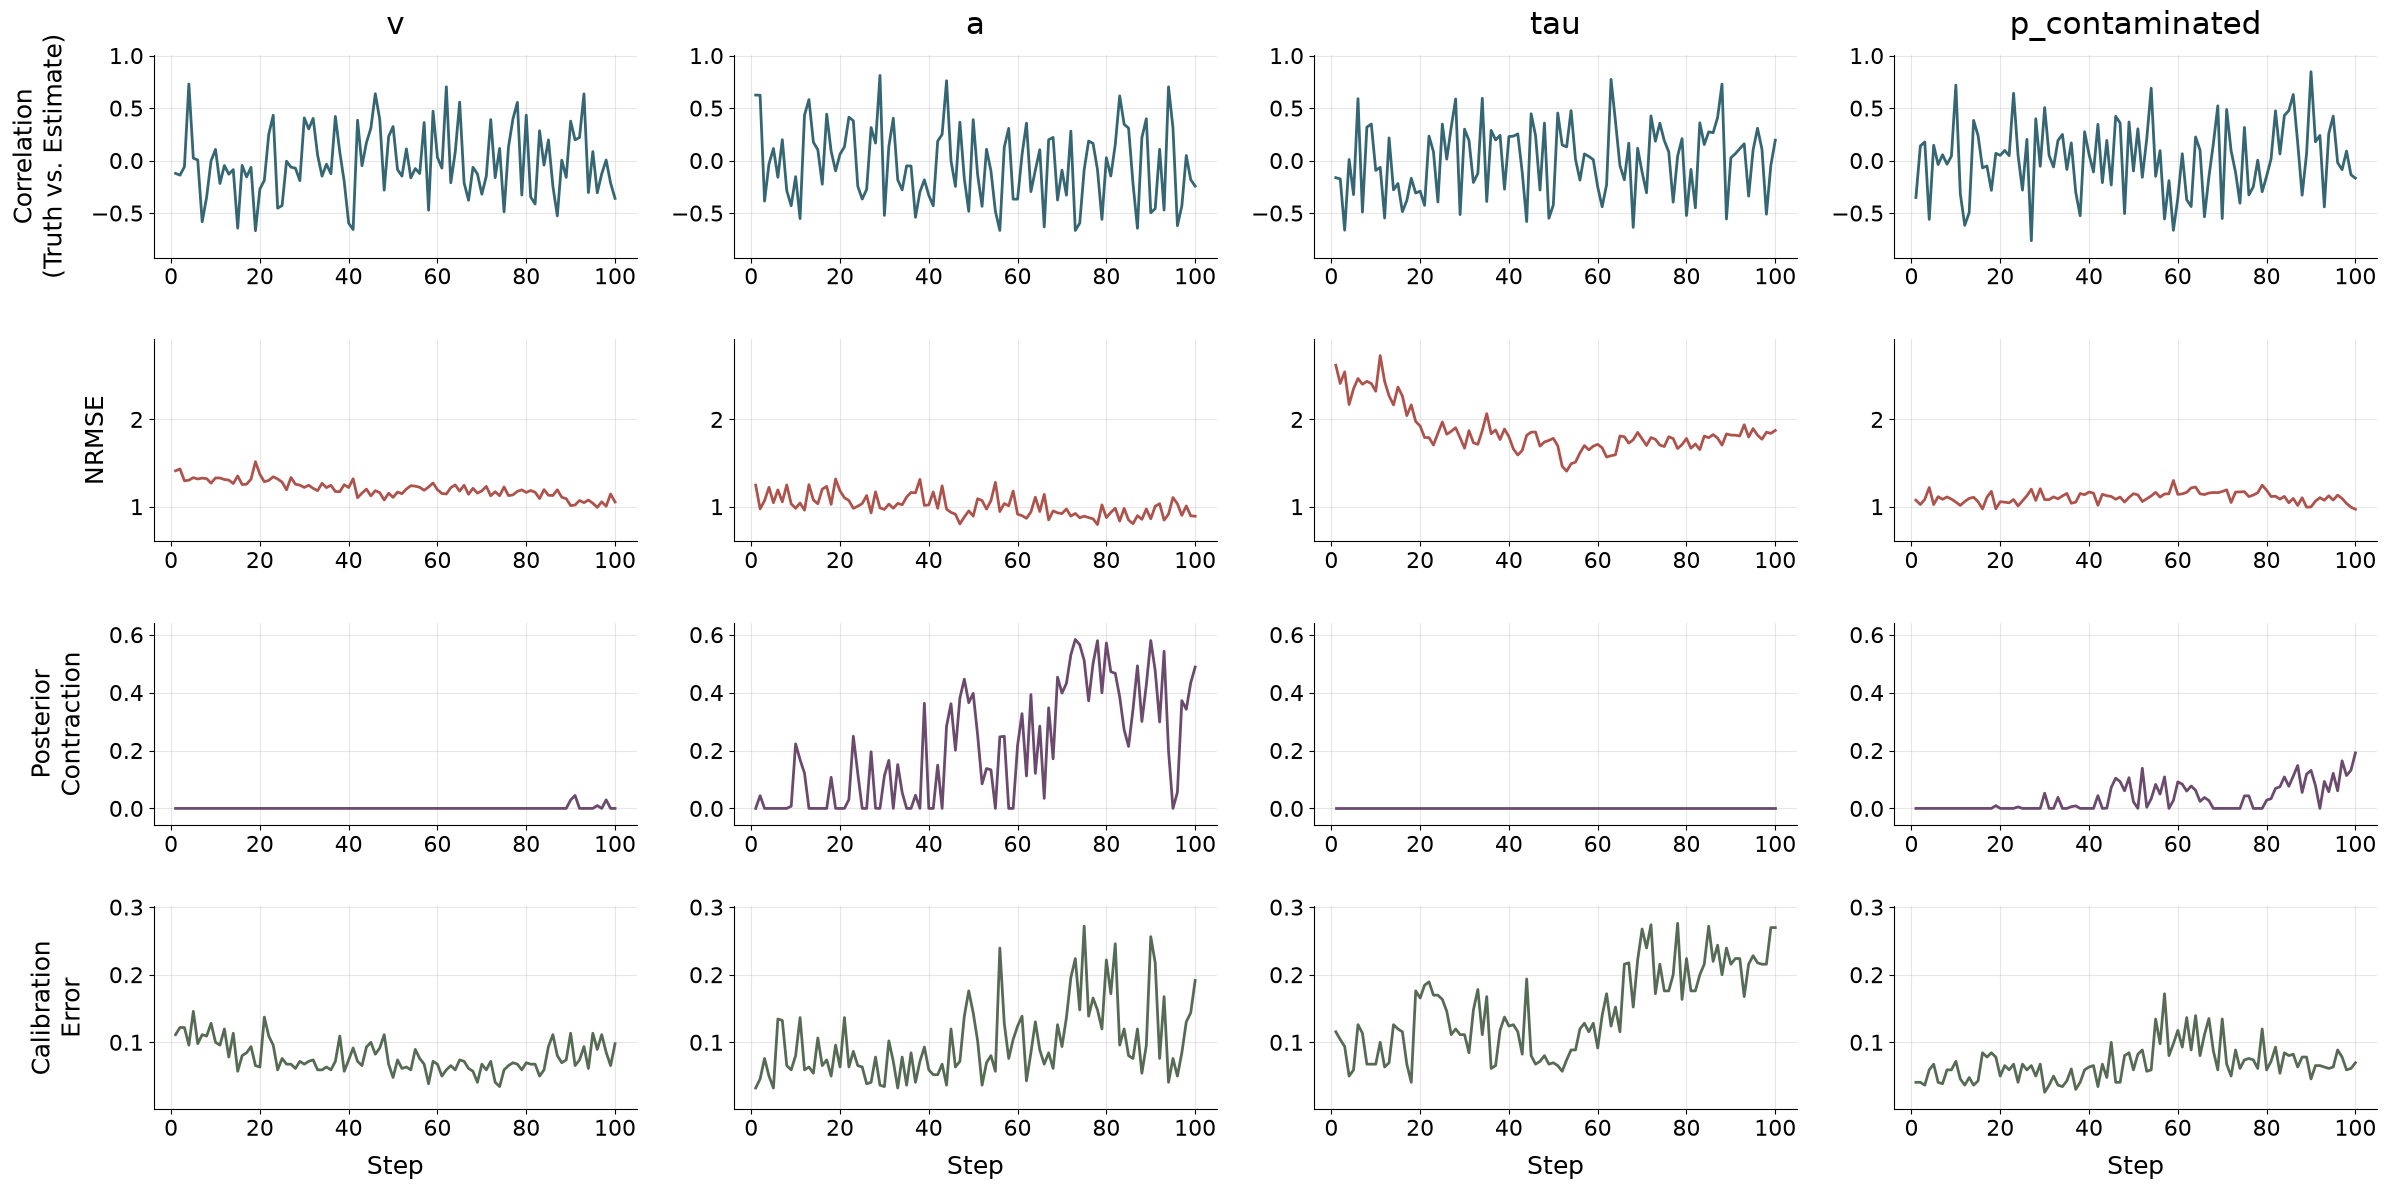

In [19]:
fig = workflow.verify_time_varying(
    targets=val_data,
    estimates=samples
)

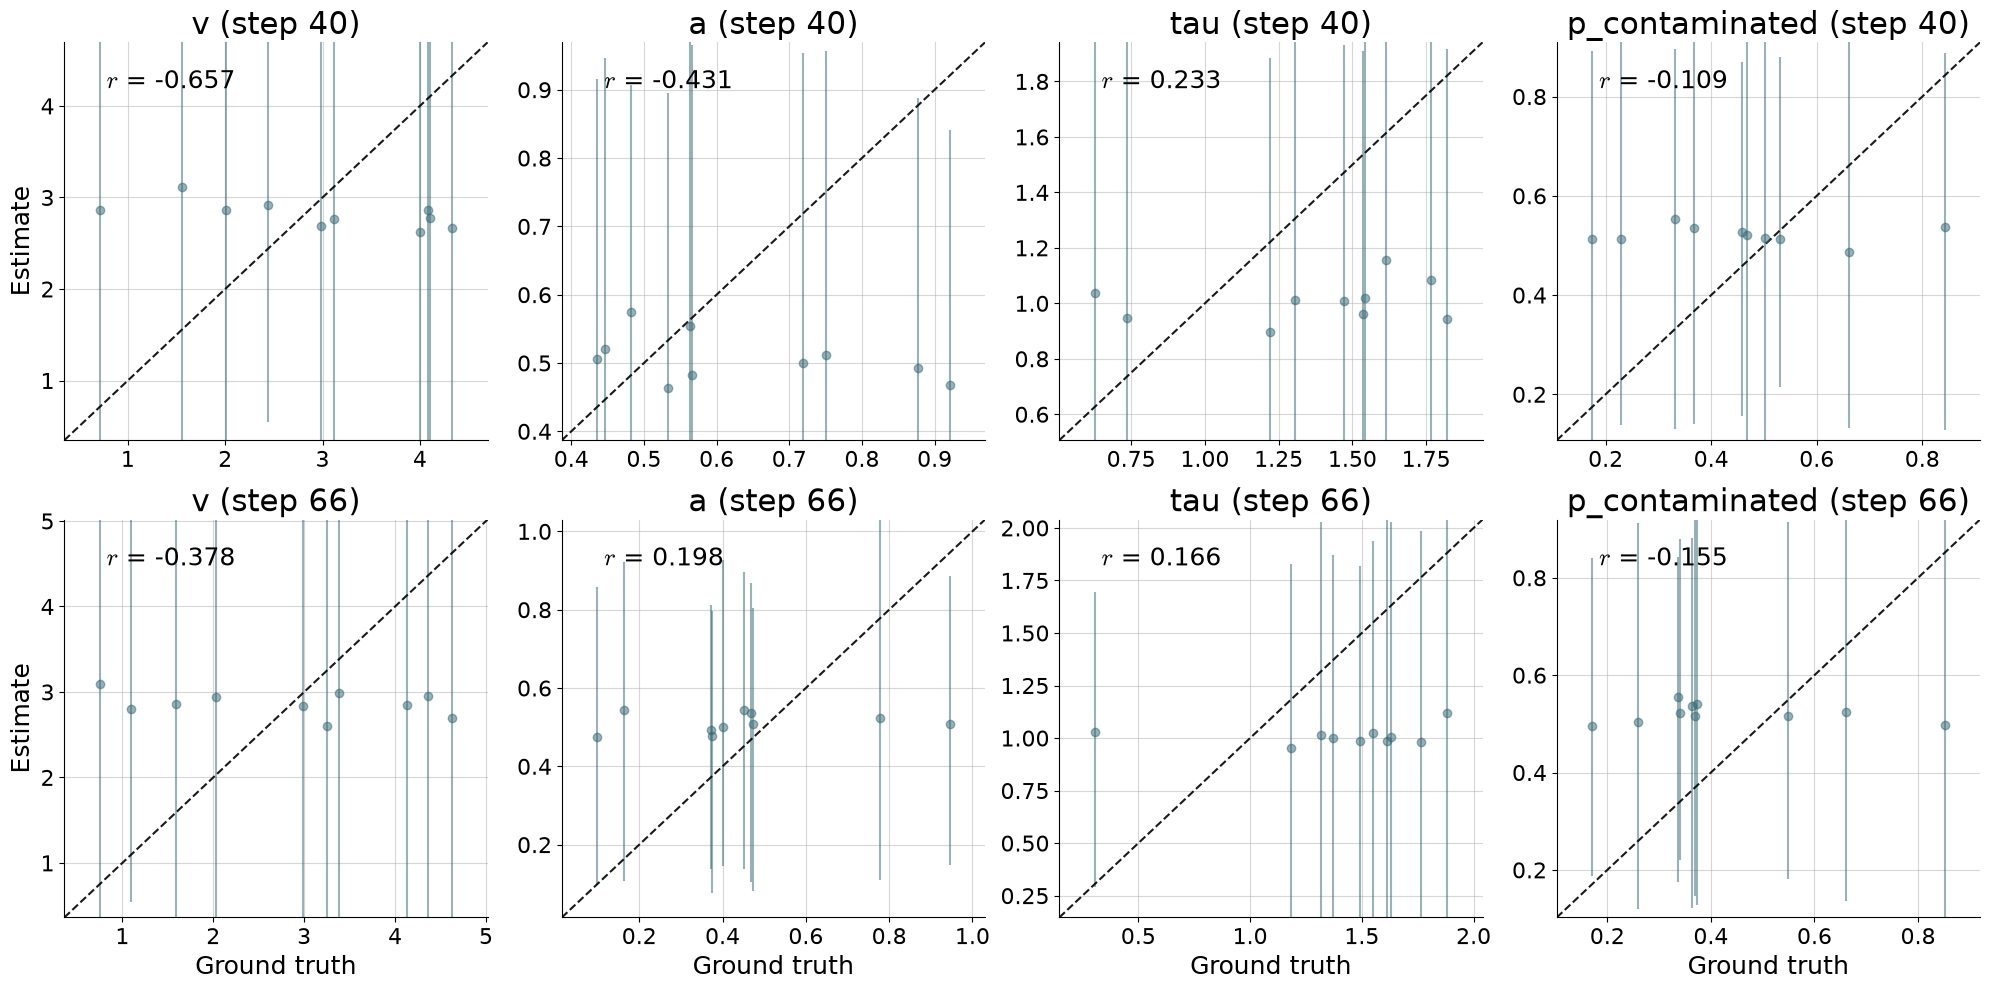

In [20]:
fig = workflow.recovery_at_steps(
    targets=val_data,
    estimates=samples,
    time_steps=[40, 66]
)

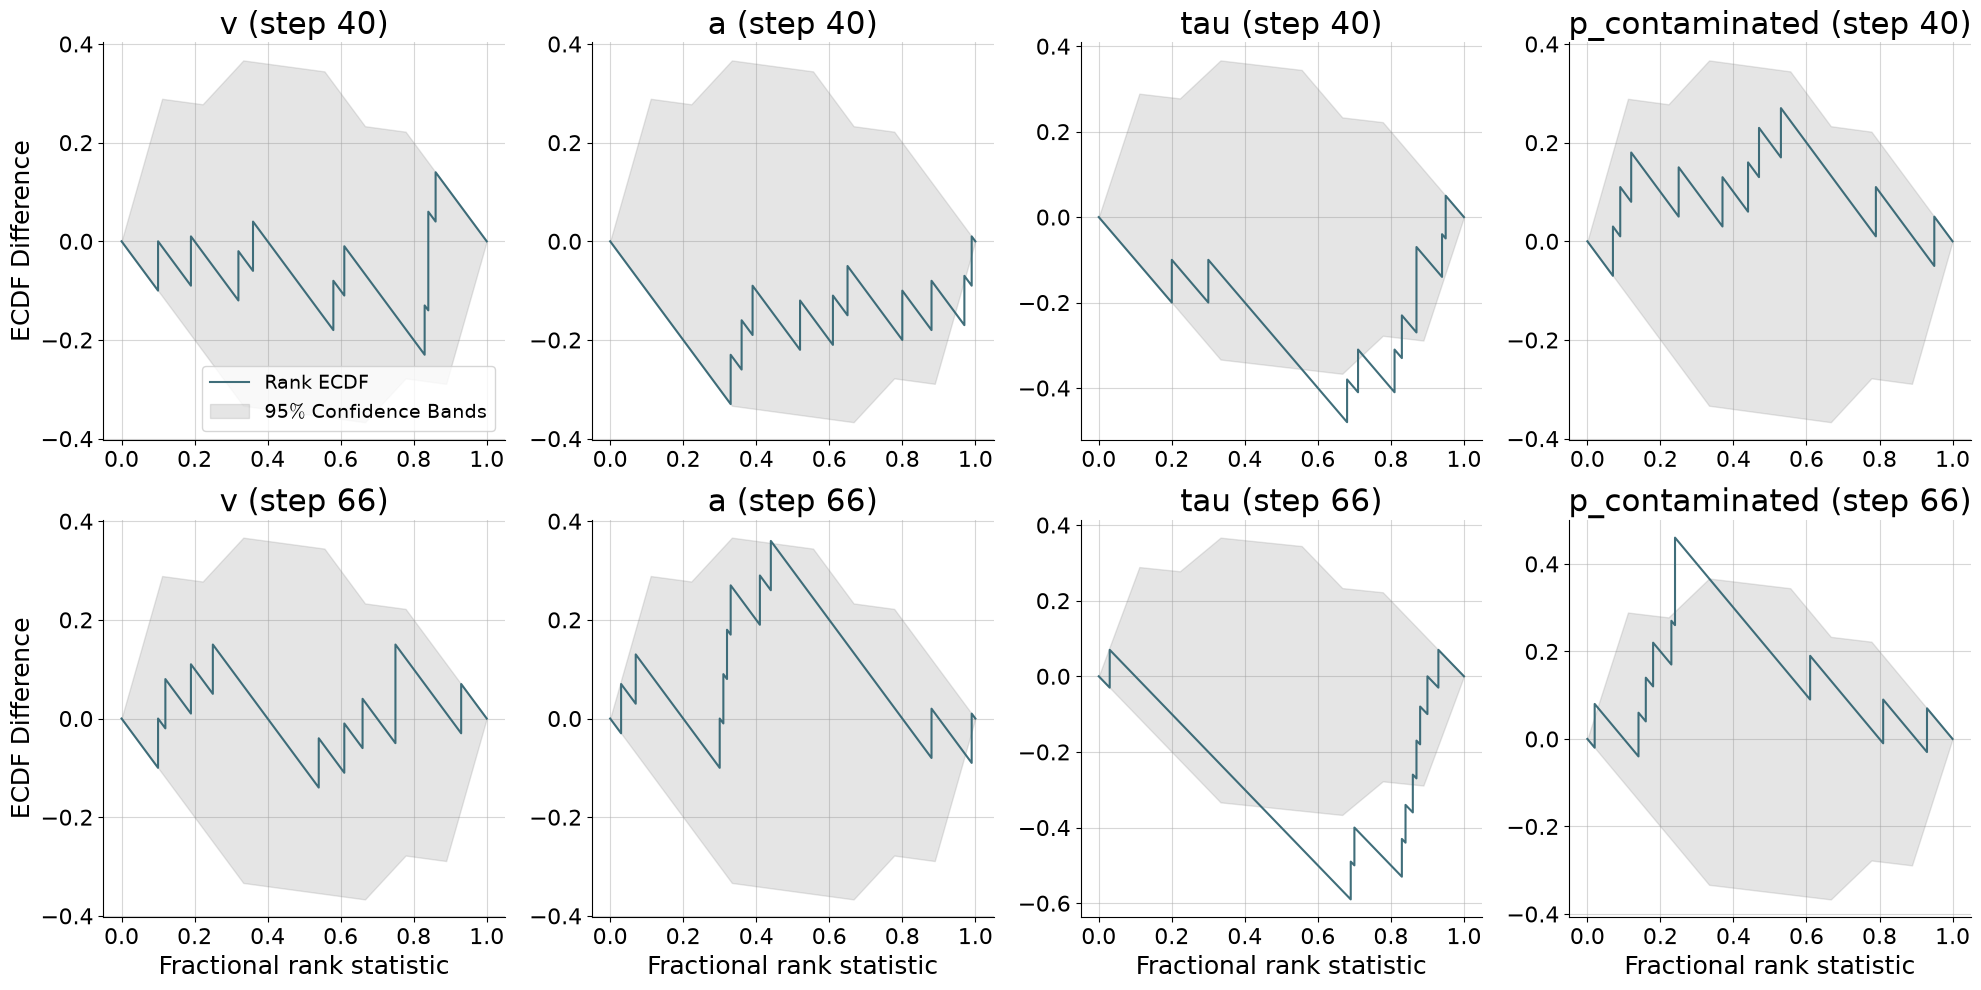

In [21]:
fig = workflow.calibration_at_steps(
    targets=val_data,
    estimates=samples,
    time_steps=[40, 66]
)

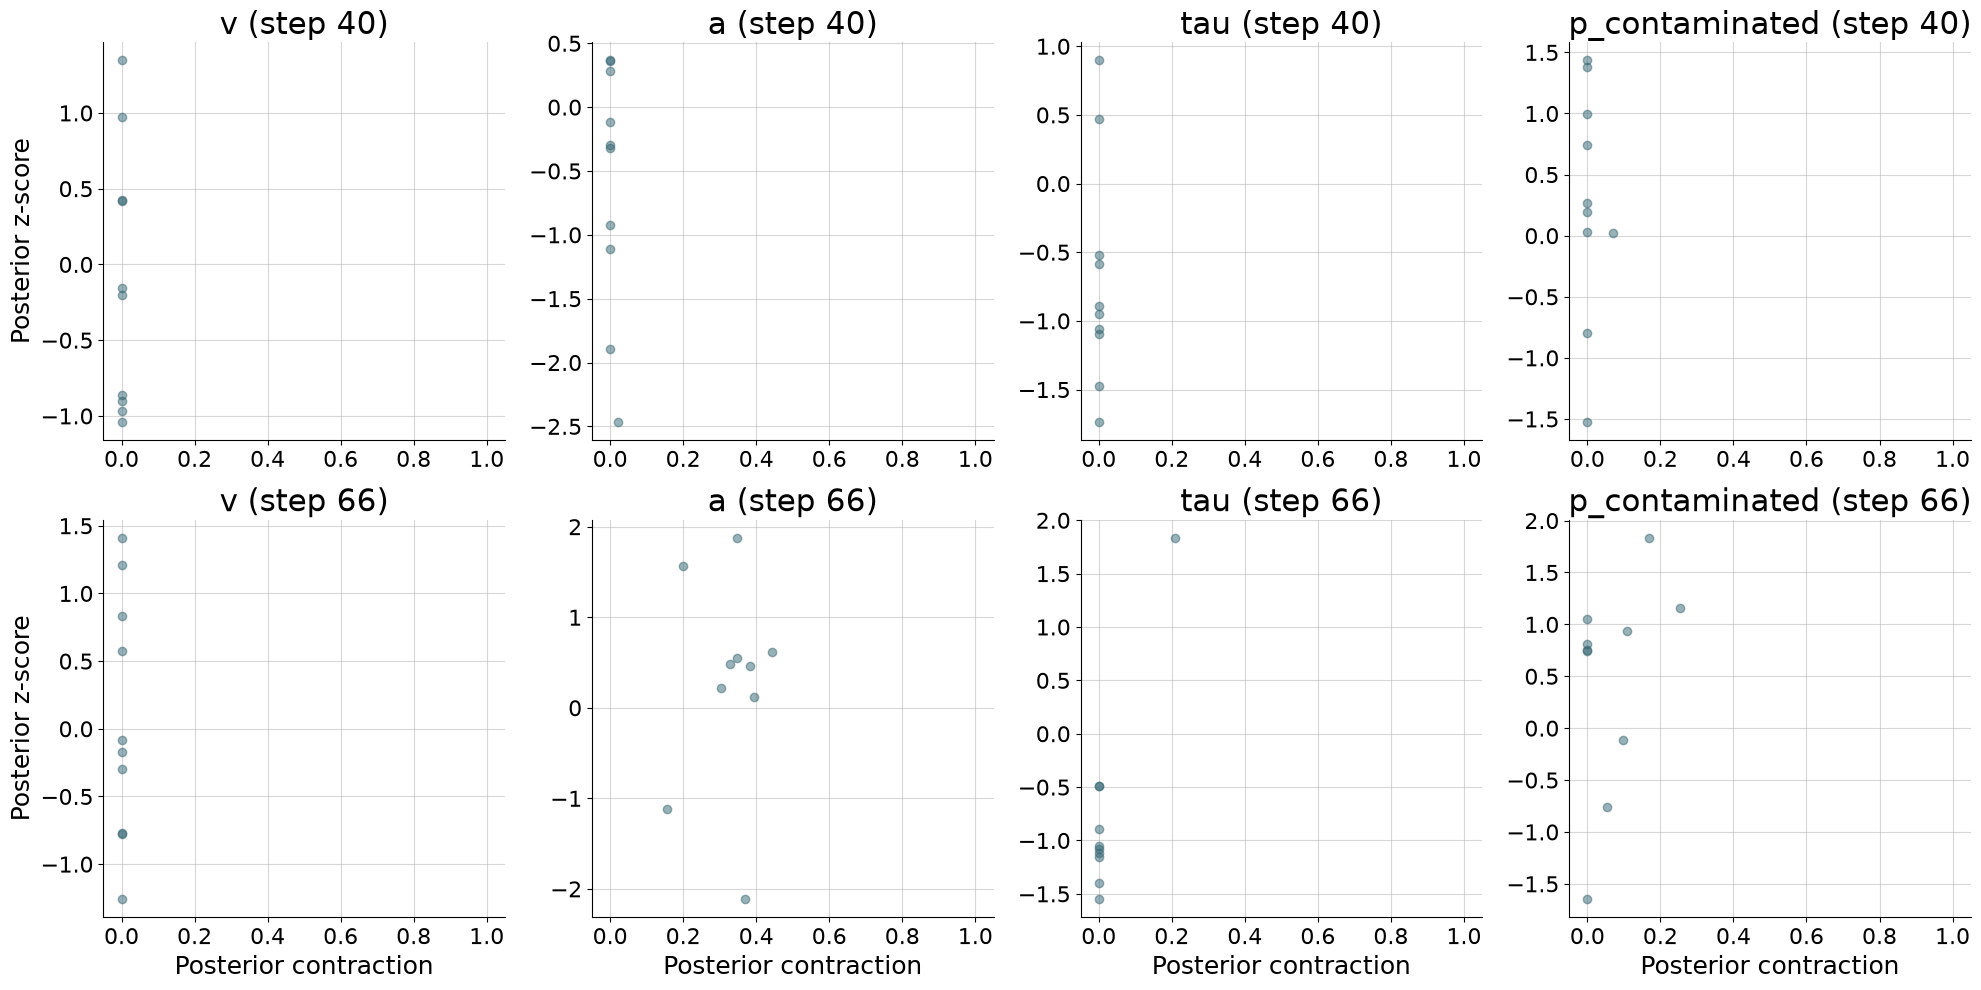

In [22]:
fig = workflow.z_score_contraction_at_steps(
    targets=val_data,
    estimates=samples,
    time_steps=[40, 66]
)

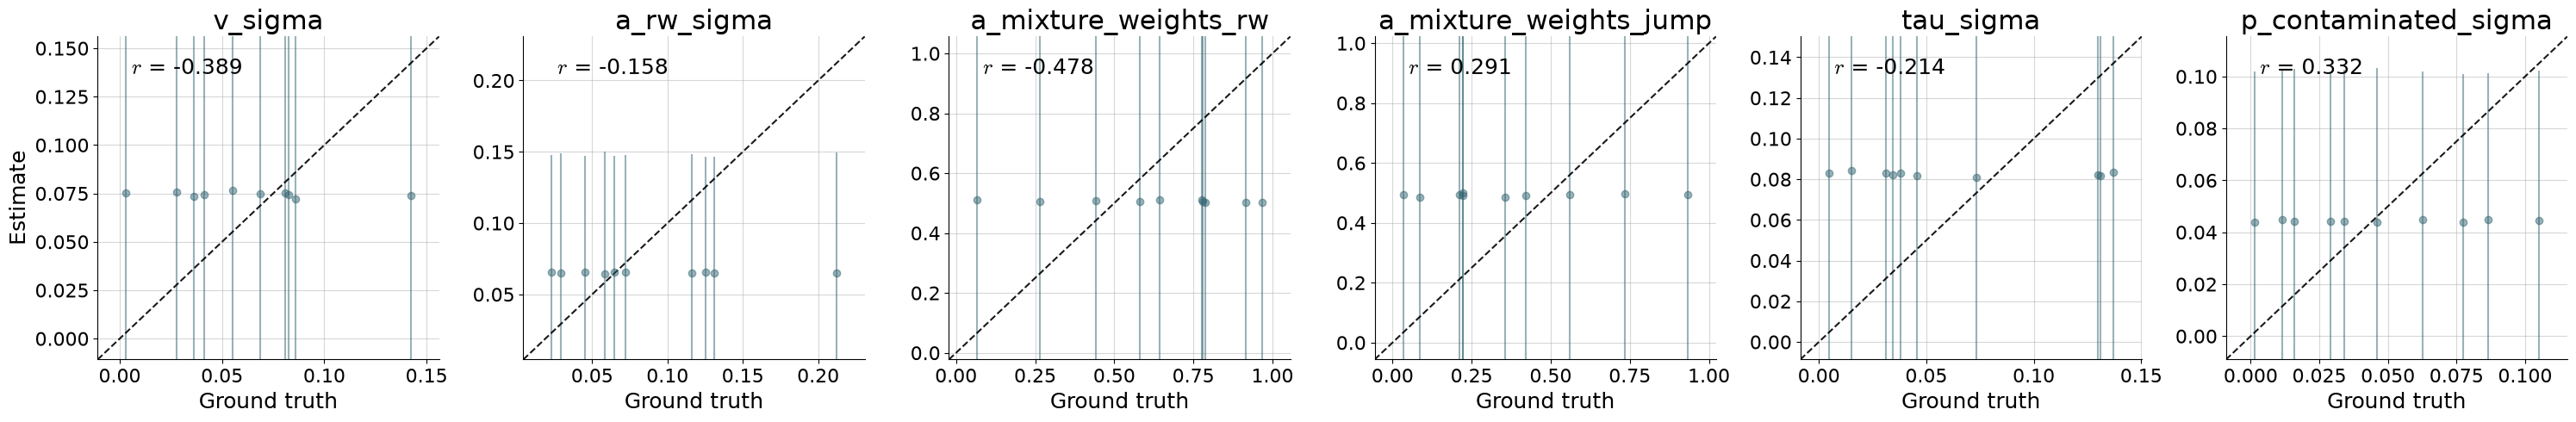

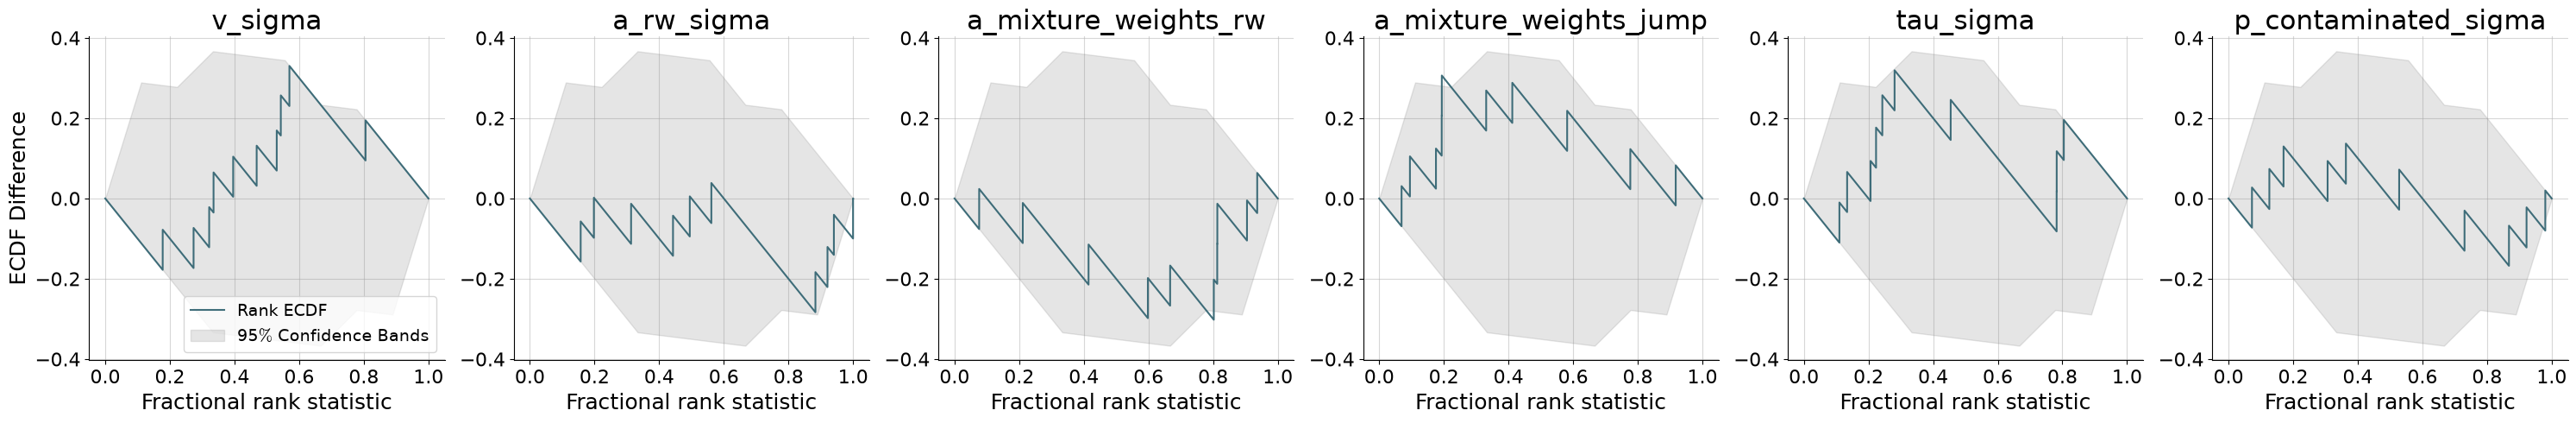

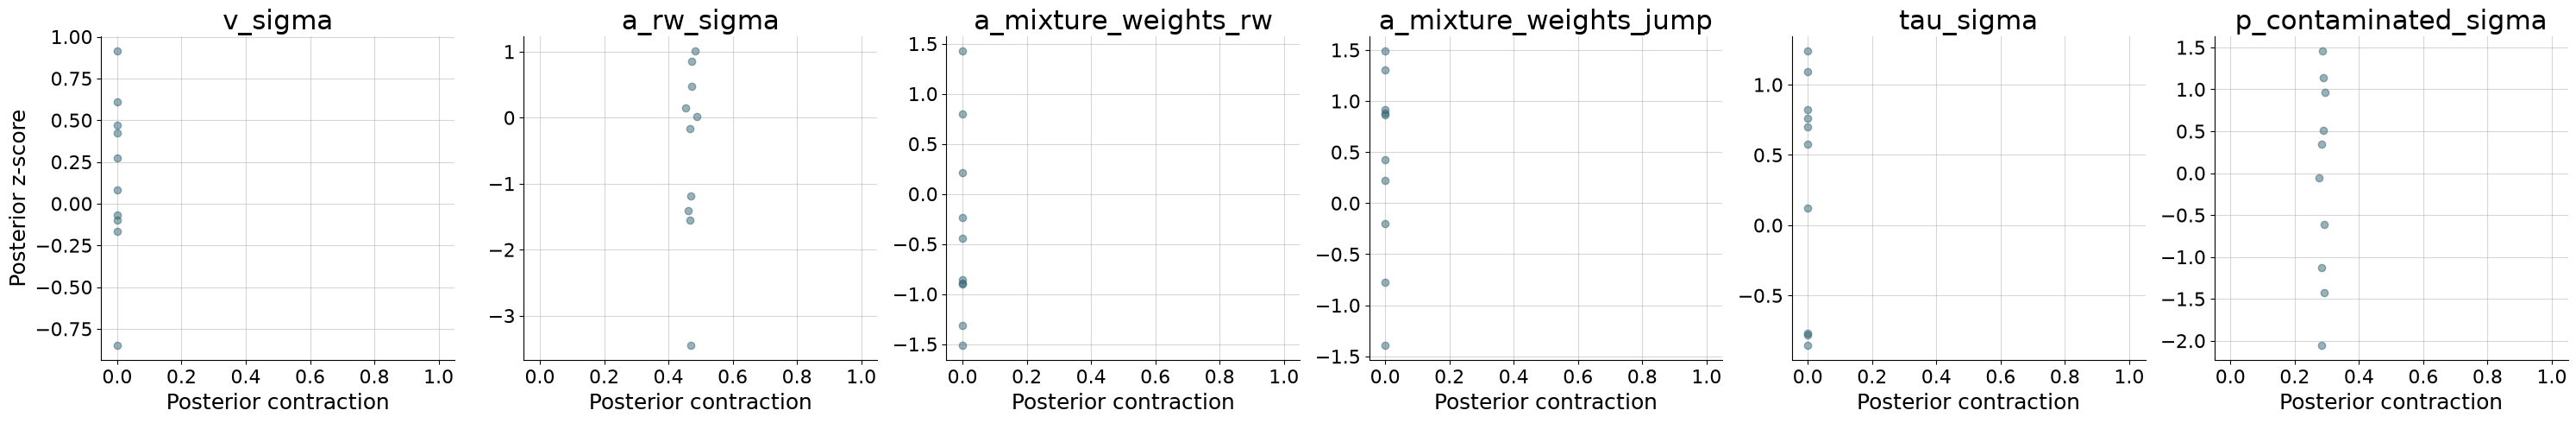

In [23]:
fig = workflow.verify_time_invariant(
    targets=val_data,
    estimates=samples
)

In [24]:
resim_data = workflow.resimulate(
    samples,
    num_sims=10
)

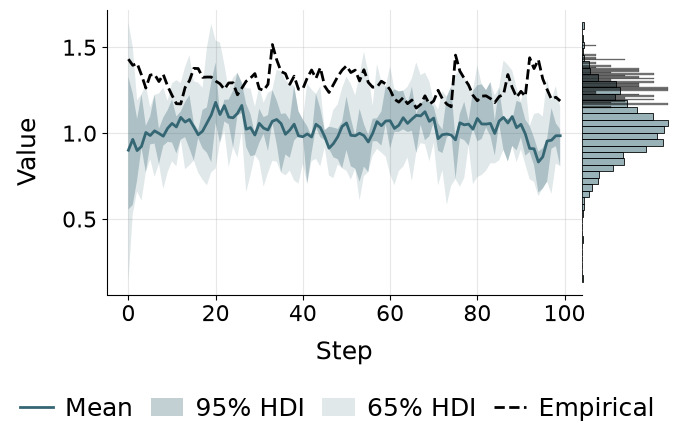

In [25]:
fig = sup.diagnostics.plot_posterior_resimulation(
    prediction=resim_data,
    empirical=val_data,
    # kind="dist",
    aggregation=np.mean,
    smoothing="ema",
    num_bins=40,
    data_idx=[1, 2],
    # dist_type="kde"
)

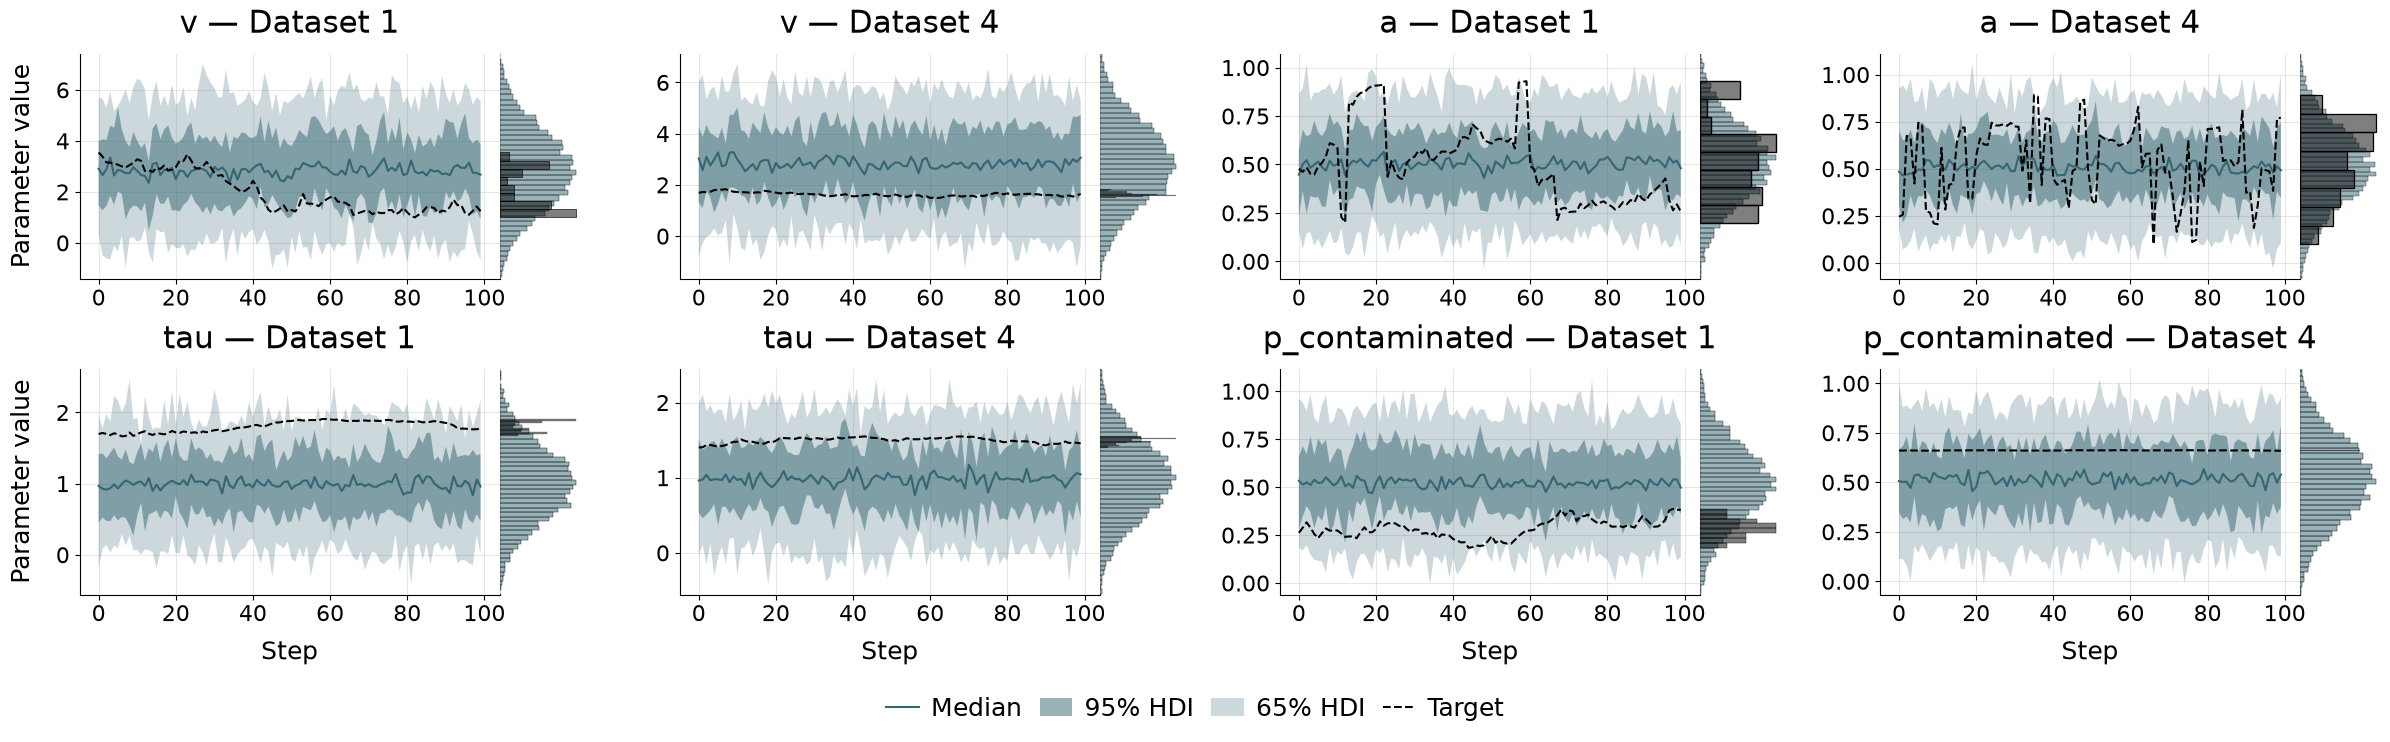

In [26]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    targets=val_data,
    # aggregation=np.median,
    data_idx=[1, 4],
    # num_cols=1
)

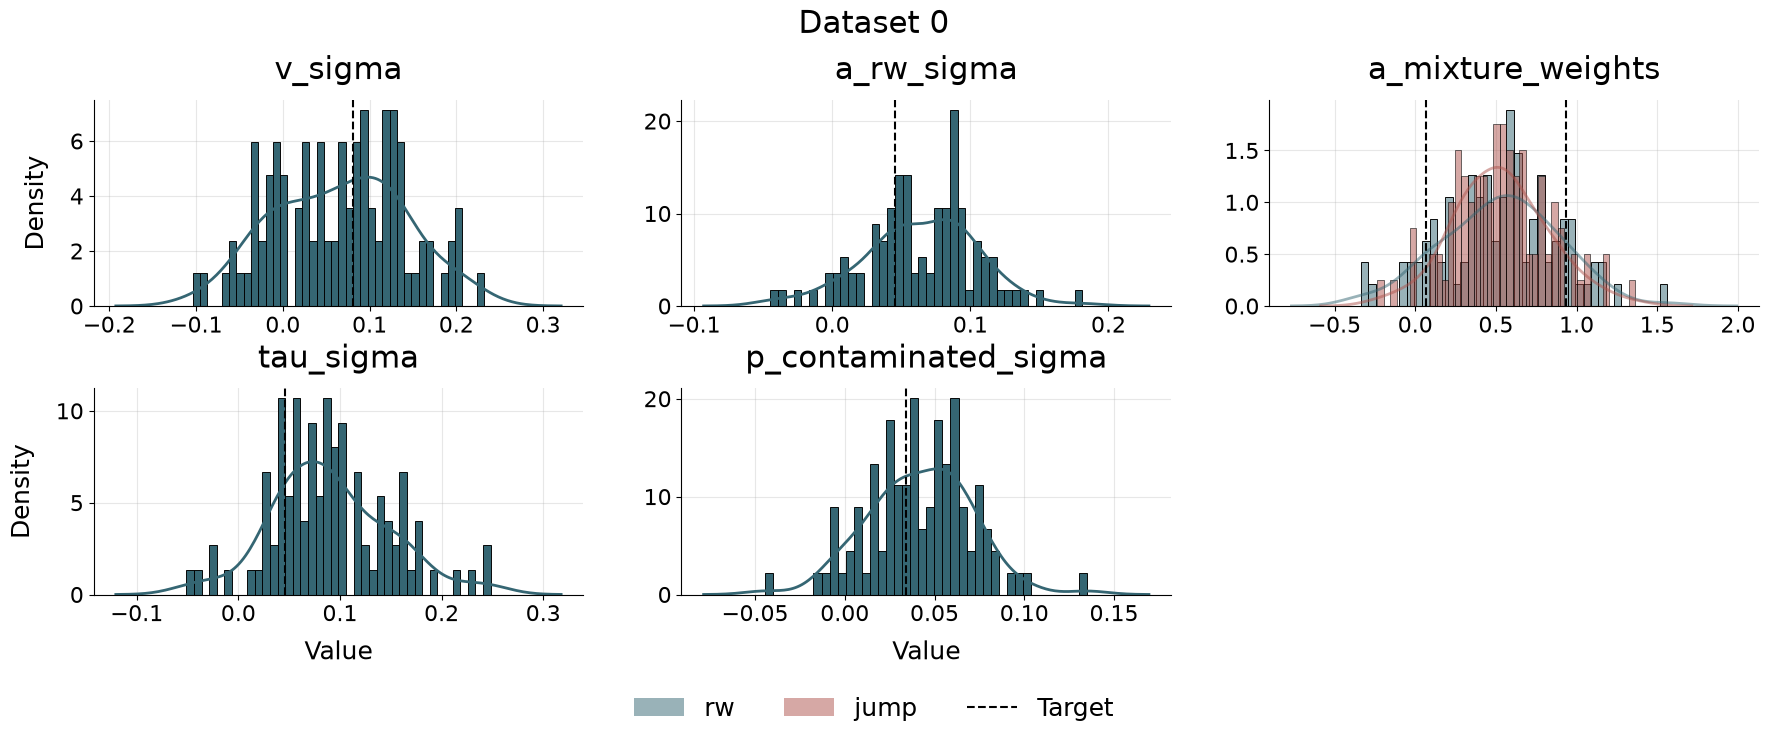

In [27]:
fig = workflow.plot_marginals(
    estimates=samples,
    targets=val_data,
    data_idx=0,
    dist_type="both",
    num_bins=40,
)

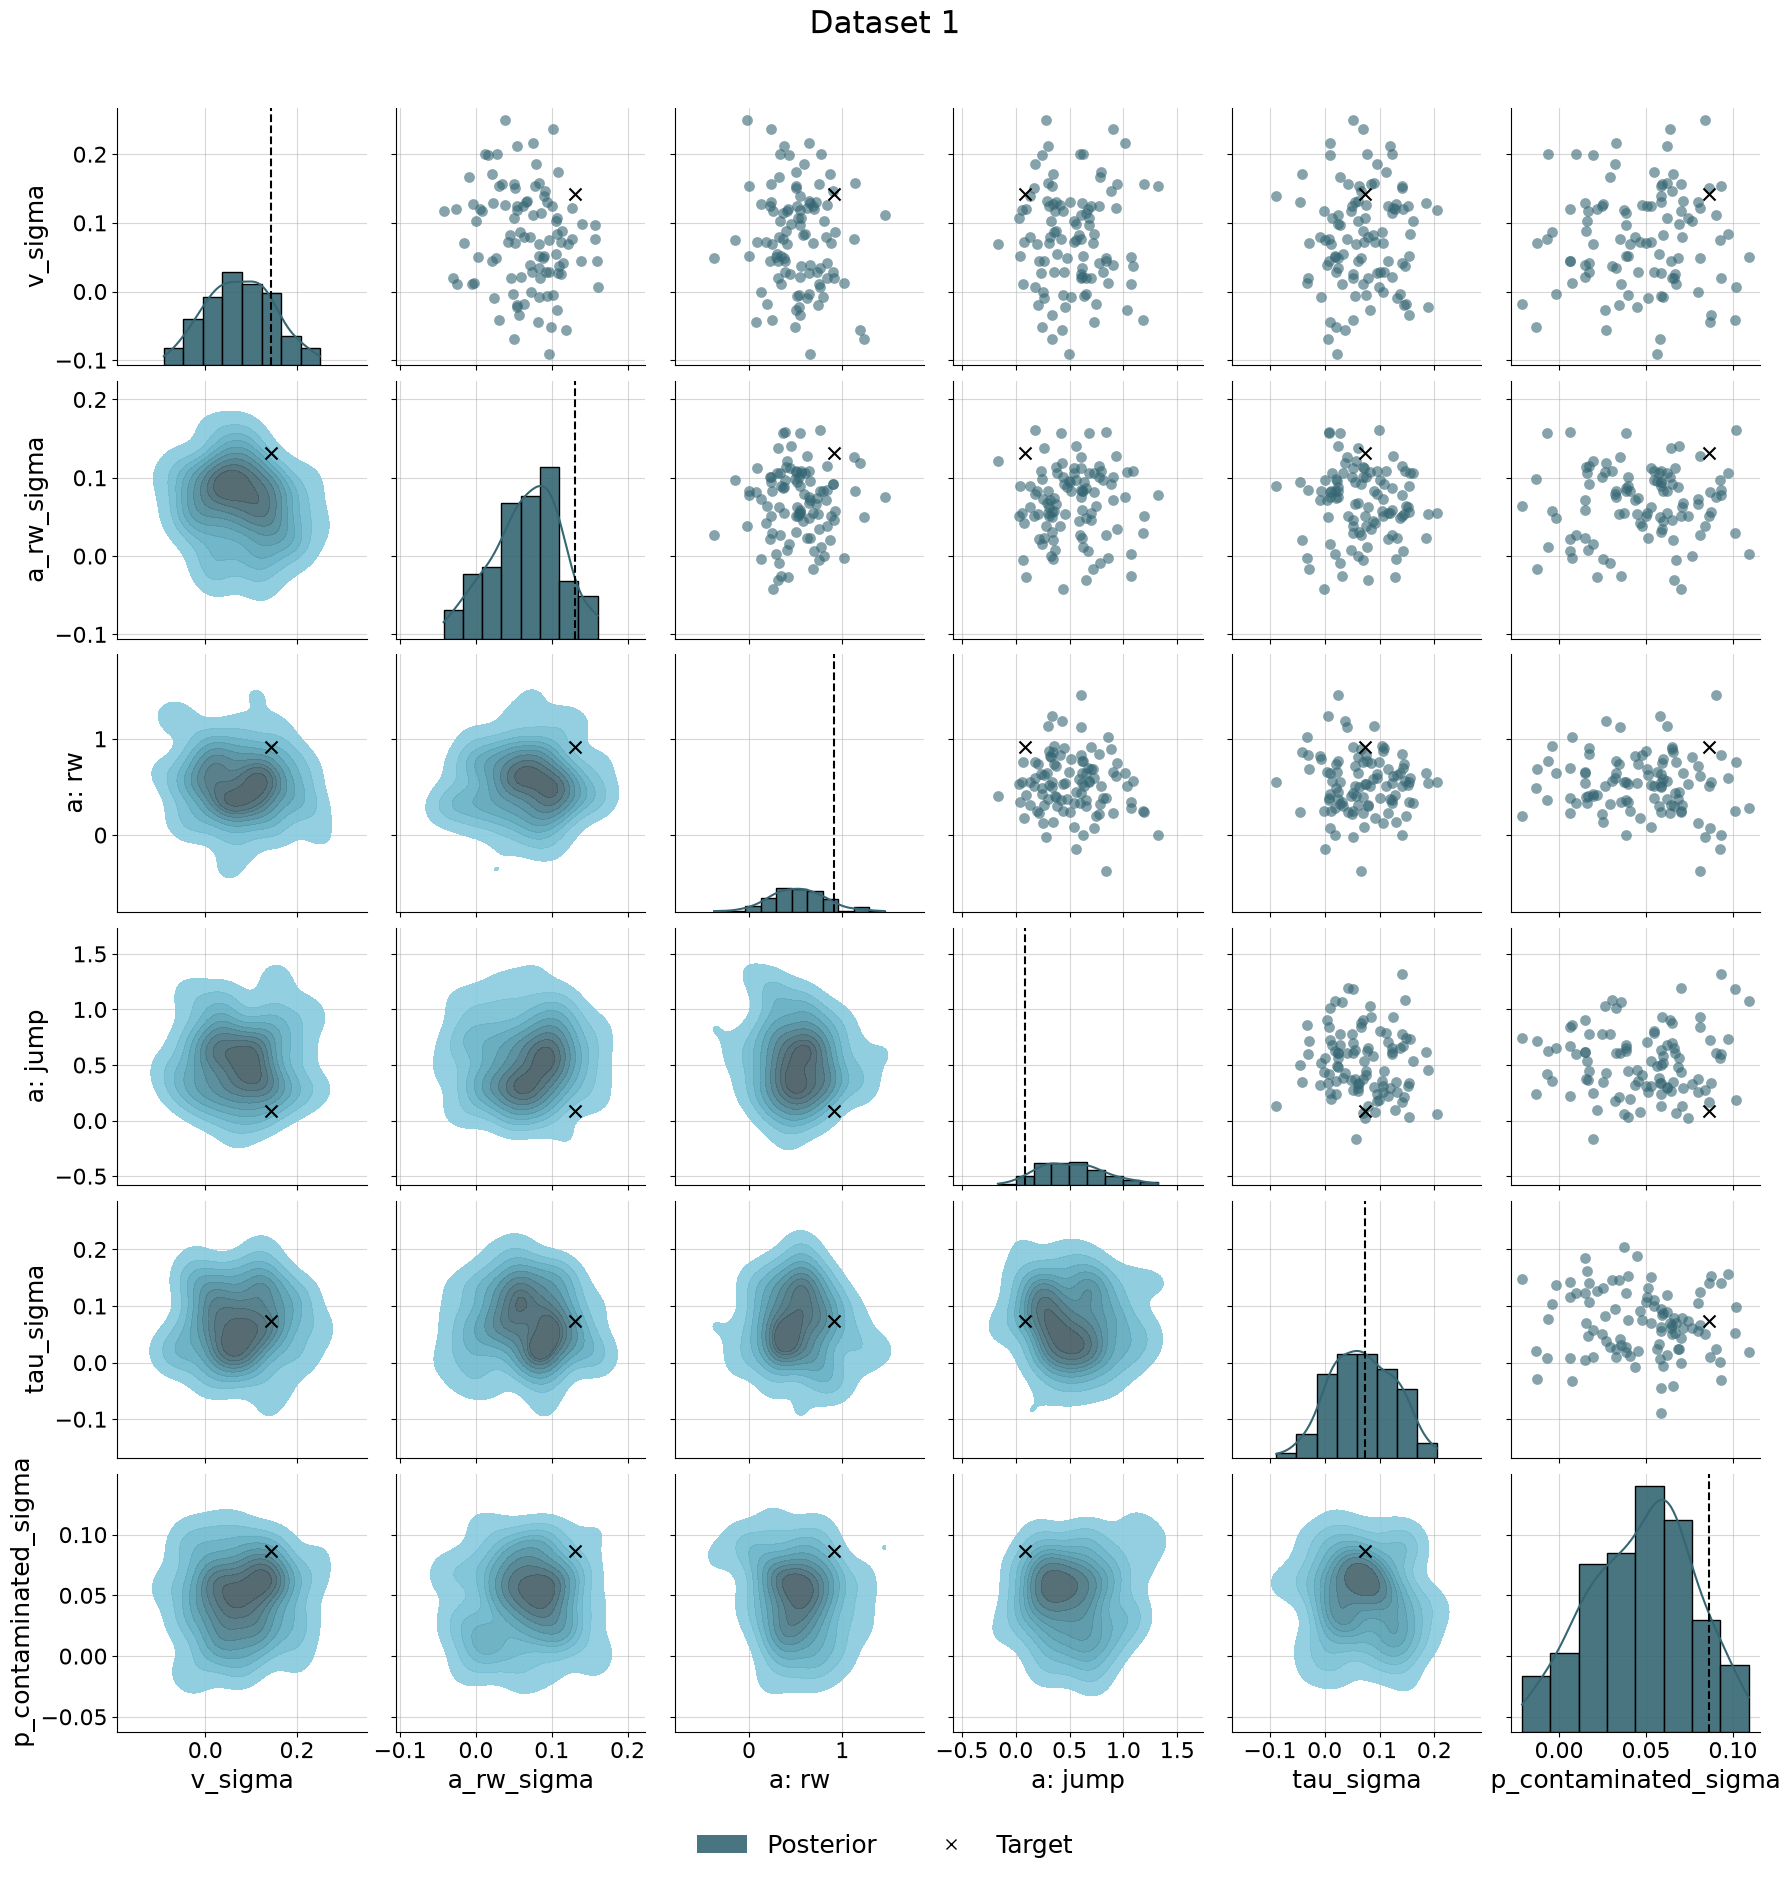

In [28]:
fig = workflow.plot_pairs(
    estimates=samples,
    targets=val_data,
    data_idx=1,
)

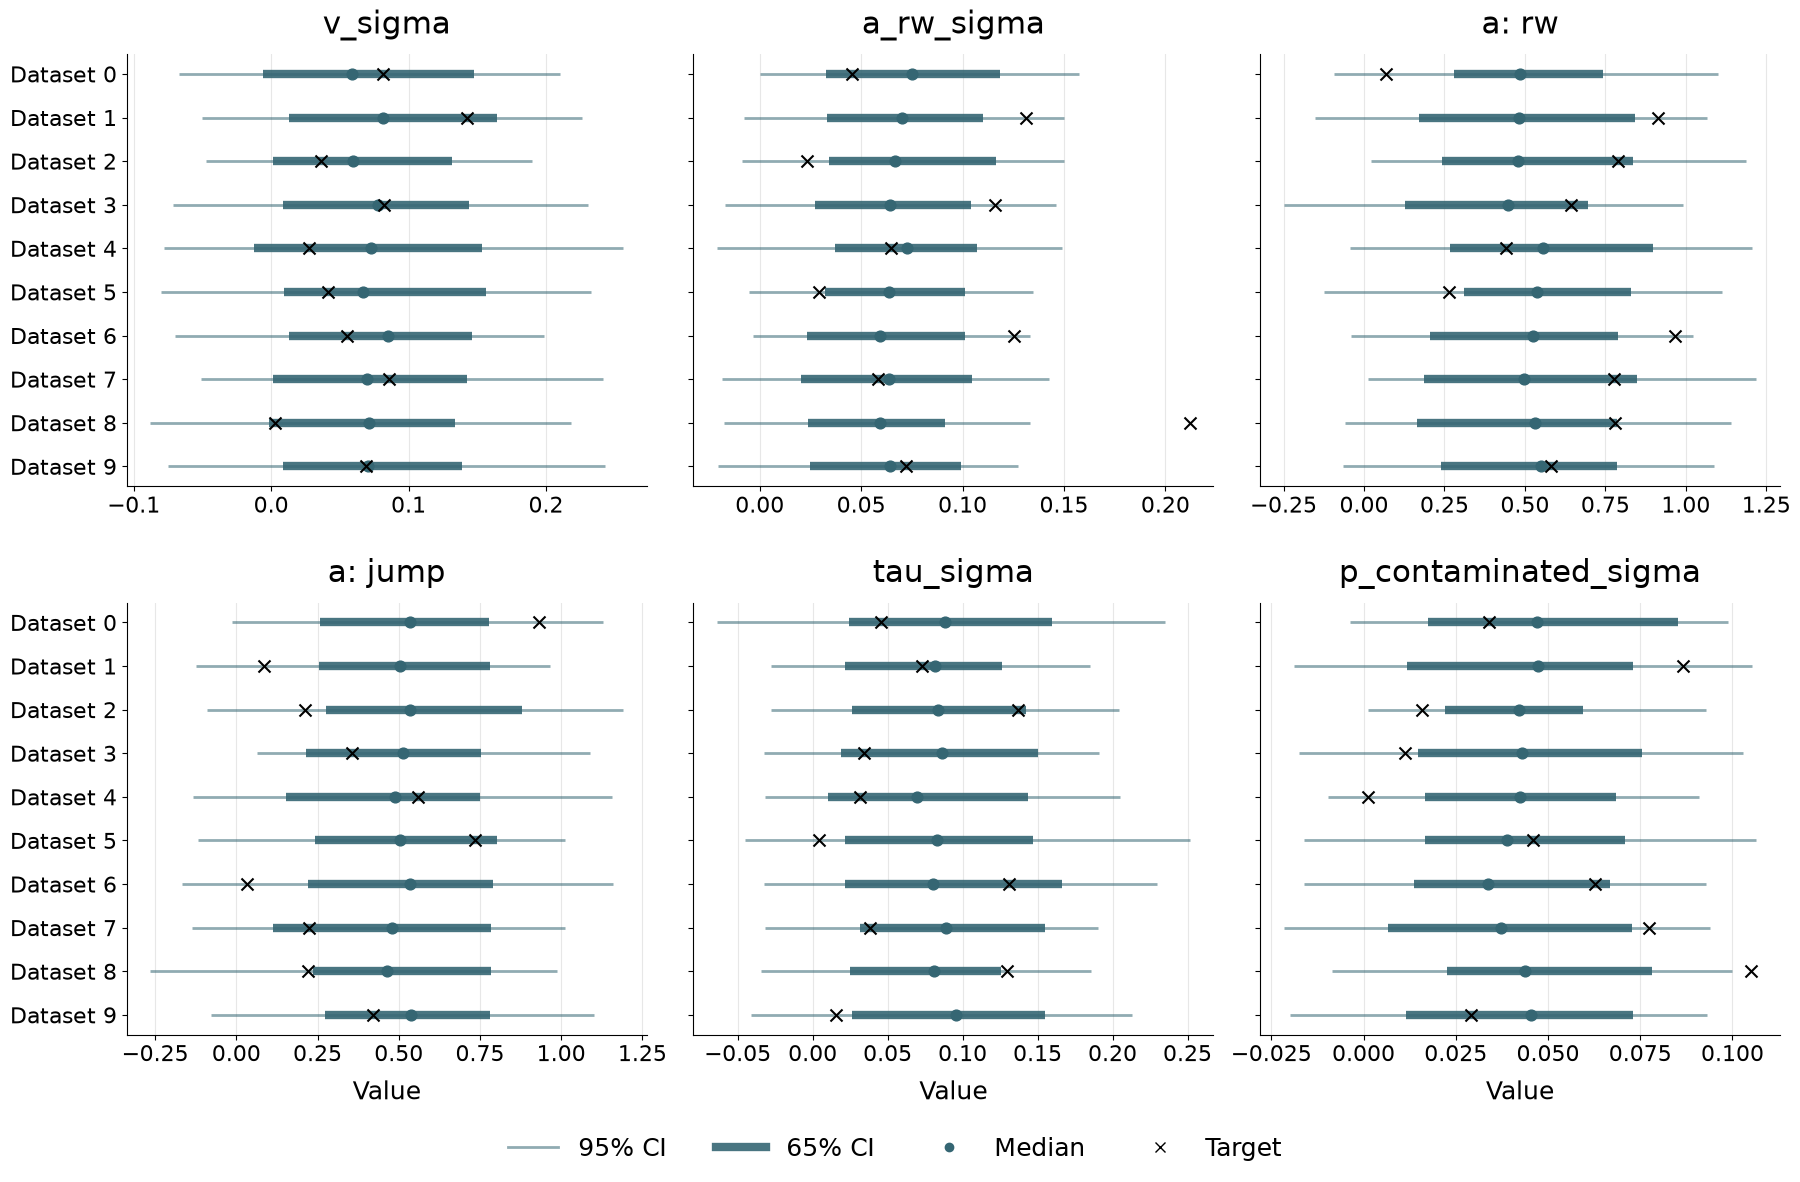

In [29]:
fig = workflow.plot_forest(
    estimates=samples,
    targets=val_data,
)

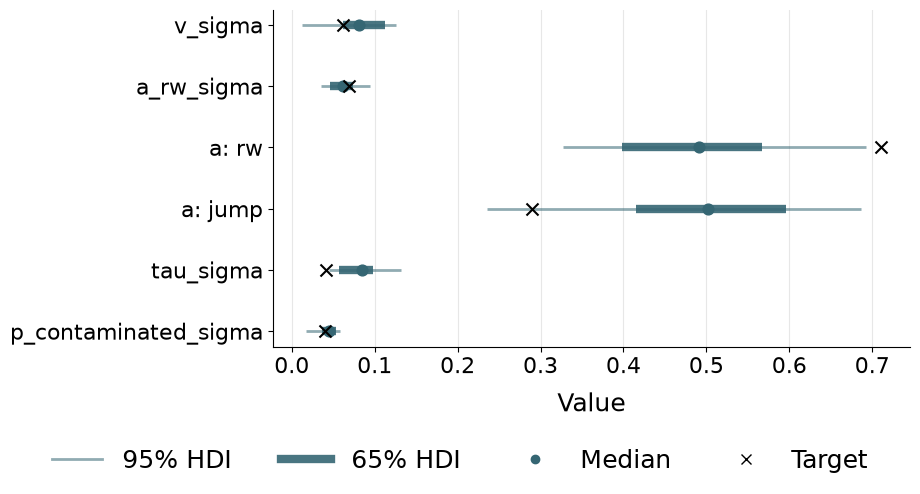

In [30]:
fig = workflow.plot_forest(
    estimates=samples,
    targets=val_data,
    aggregation=np.median
)